<center>

# Copernicus Data Store (CDS) Interpolation Pipeline Utilizing Python 
### By Matthew Tu
#### December 2025

</center>

---

# CDS API Data Collection

---

### Creating CDS Request

In [2]:
# EVENT COINFIGURATION
region = 'South China Sea'  # Choose: 'North America', 'Europe', 'South China Sea'
year = "2025"
month = "09"
day_start = 17; day_end = 25
name = "Typhoon_Ragasa"

# Fixed regional coordinate grids
Regions = {
    'North America': [50, -110, 0, -60],      # [North, West, South, East]
    'Europe': [75, -25, 35, 40],
    'South China Sea': [40, 100, 0, 150],    # 45 to -15 N, 90 to 155 E [50x65 degree box]
}

# Generate day list
days = [f"{day:02d}" for day in range(day_start, day_end + 1)]
days

# Your Hurricane Katrina request
era5_request = {
    'product_type': 'reanalysis',
    'variable': [
        'u_component_of_wind',
        'v_component_of_wind', 
        'vertical_velocity',
        'temperature',
        #'specific_humidity',
        # 'geopotential',
        # 'relative_humidity',
        # 'divergence'
    ],
    'area': Regions[region], 
    'pressure_level': [
        '1000', '950', '900', '850', '700', '650', '600', 
        '550', '500', '450', '400'#, '350', '300', '250', 
        #'200', '150', '100', '50'
    ],
    'year': [year],
    'month': [month],
    'day': days,
    'time': [f"{hour:02d}:00" for hour in range(0, 24, 6)], # change 6 to 3 for 6 to 3-hourly data
    'grid': [0.25, 0.25],
    'format': 'netcdf',
    'expver': '1',
    'levtype': 'pl',
    'stream': 'oper',
    'type': 'an'
}

---

### Calling With The Request and Splicing a Land Layer Directly to the specified ERA5 Data

2025-12-23 09:25:33,256 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


Request: 4 variables, 9 days


2025-12-23 09:25:34,417 INFO Request ID is aa8930c7-c92e-4994-aba6-14607da487bf
2025-12-23 09:25:34,630 INFO status has been updated to accepted
2025-12-23 09:25:57,852 INFO status has been updated to running
2025-12-23 09:28:30,408 INFO status has been updated to successful


38b764e82f8257940af962a5ae7aa5ab.nc:   0%|          | 0.00/115M [00:00<?, ?B/s]

Download complete: typhoon_ragasa_era5.nc
Typhoon_Ragasa data downloaded successfully!
File: typhoon_ragasa_era5.nc
Loading datasets...
Detected GLORYS ocean data

Top depth level in GLORYS: 0.49402499198913574 meters
Top pressure level in ERA5: 1000.0 mb


Region: South China Sea
Lat range: 0 to 40
Lon range: 100 to 150

Ocean data longitude convention check:
  Lon range in file: -180.00 to 179.92
  -> Using -180/180 convention
Ocean data lon range for selection: 100 to 150

DEBUG: LATITUDE COORDINATE ORDERING CHECK

GLORYS latitude range: -80.00 to 90.00
GLORYS latitude order: ASCENDING
GLORYS first 5 lats: [-80.       -79.916664 -79.833336 -79.75     -79.666664]
GLORYS last 5 lats: [89.666664 89.75     89.833336 89.916664 90.      ]

ERA5 latitude range: 0.00 to 40.00
ERA5 latitude order: DESCENDING
ERA5 first 5 lats: [40.   39.75 39.5  39.25 39.  ]
ERA5 last 5 lats: [1.   0.75 0.5  0.25 0.  ]

GLORYS and ERA5 have opposite latitude ordering!
This will cause spatial misalignment whe

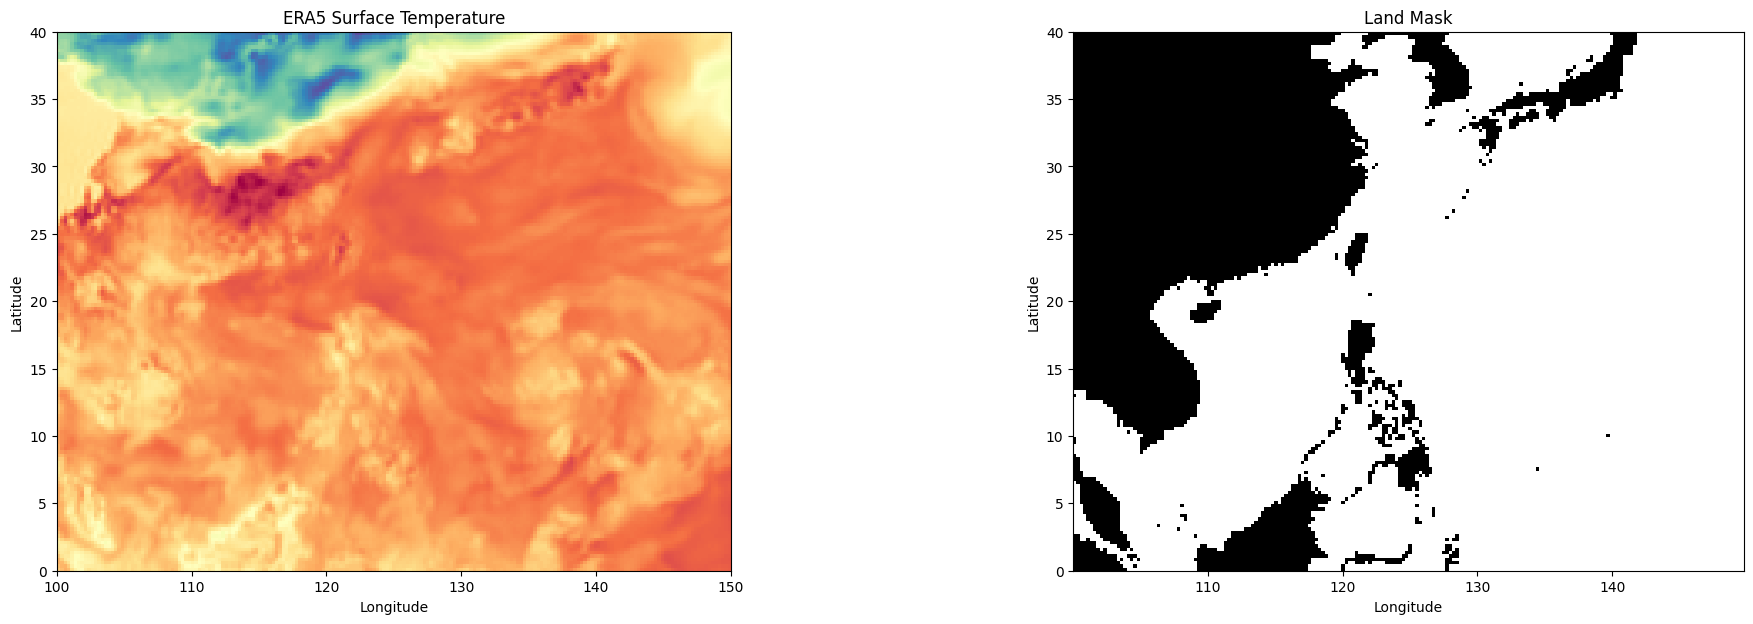

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import os

from cds_Downloader import download_era5_data, download_oras5, add_land_mask_to_era5

###############################################
# Download ERA5 Data [CDS API]
###############################################

output_filename = f'{name.lower()}_era5.nc'

# Download the data
success, output_file = download_era5_data(era5_request,
                            output_filename = output_filename)
if success:
    print(f"{name} data downloaded successfully!")
    print(f"File: {output_file}")
else:
    print("Download failed - check your request and credentials.")

#############################################
# Adding Land Mask from ORAS5 to ERA5 Data
#############################################

file_land = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\cmems_mod_glo_phy_my_0.083deg-climatology_P1M-m_1766187275572.nc"
file_ERA = output_filename  # Use the ERA5 file, not ORAS5
output_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{name.lower()}_era5_with_land.nc"

# Run the function to add land mask
add_land_mask_to_era5(file_land, file_ERA, output_file, Regions, region)


Loading datasets...
Detected ORAS5 ocean data
Top pressure level in ERA5: 1000.0 mb


Region: North America
Lat range: 0 to 50
Lon range: -110 to -60

Ocean data longitude convention check:
  Lon range in file: -180.00 to 180.00
  -> Using -180/180 convention
Ocean data lon range for selection: -110 to -60

DEBUG: LATITUDE COORDINATE ORDERING CHECK

ORAS5 latitude range: -77.01 to 89.95
ORAS5 uses 2D lat/lon arrays (nav_lat, nav_lon)

ERA5 latitude range: 0.00 to 50.00
ERA5 latitude order: DESCENDING
ERA5 first 5 lats: [50.   49.75 49.5  49.25 49.  ]
ERA5 last 5 lats: [1.   0.75 0.5  0.25 0.  ]

  Latitude ordering is consistent between datasets


DEBUG: OCEAN DATASET EXTRACTION
Extracting ORAS5 data (global grid with 2D coordinates)...
ORAS5 grid shape: y=1021, x=1442
Interpolating to regular grid: 201 lats x 201 lons
Performing nearest-neighbor interpolation...


c:\Users\Matt\Downloads\CDS_To_Visual_Latest\cds_Downloader.py:252: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"ORAS5 grid shape: y={dataGLORYS.dims['y']}, x={dataGLORYS.dims['x']}")


ORAS5 data interpolated to regular grid, shape: (201, 201)


DEBUG: surfaceGLORYS_DATA AFTER SELECTION
surfaceGLORYS_DATA shape: (201, 201)
surfaceGLORYS_DATA dimensions: ('latitude', 'longitude')
Number of longitude points: 201
Number of latitude points: 201


DEBUG: landData IMMEDIATELY AFTER CREATION
landData shape: (201, 201)
landData dimensions: ('latitude', 'longitude')
landData longitude size: 201
landData longitude range: -110.00 to -60.00
landData latitude size: 201
landData latitude range: 0.00 to 50.00

ERA5 file shape: (201, 201)
Landmask shape: (201, 201)

Landmask Data Type: float32
ERA5 Surface Data Type: float32

Adding the land mask into ERA5 dataset...
Getting current pressure levels...
Adding sea level pressure...
Matching dimensions...
Aligning coordinates...

DEBUG: LAND MASK COORDINATES BEFORE REASSIGNMENT

LandData latitude range: 0.00 to 50.00
LandData latitude order: ASCENDING
LandData first 5 lats: [0.   0.25 0.5  0.75 1.  ]
LandData last 5 lats: [49.   49.25 

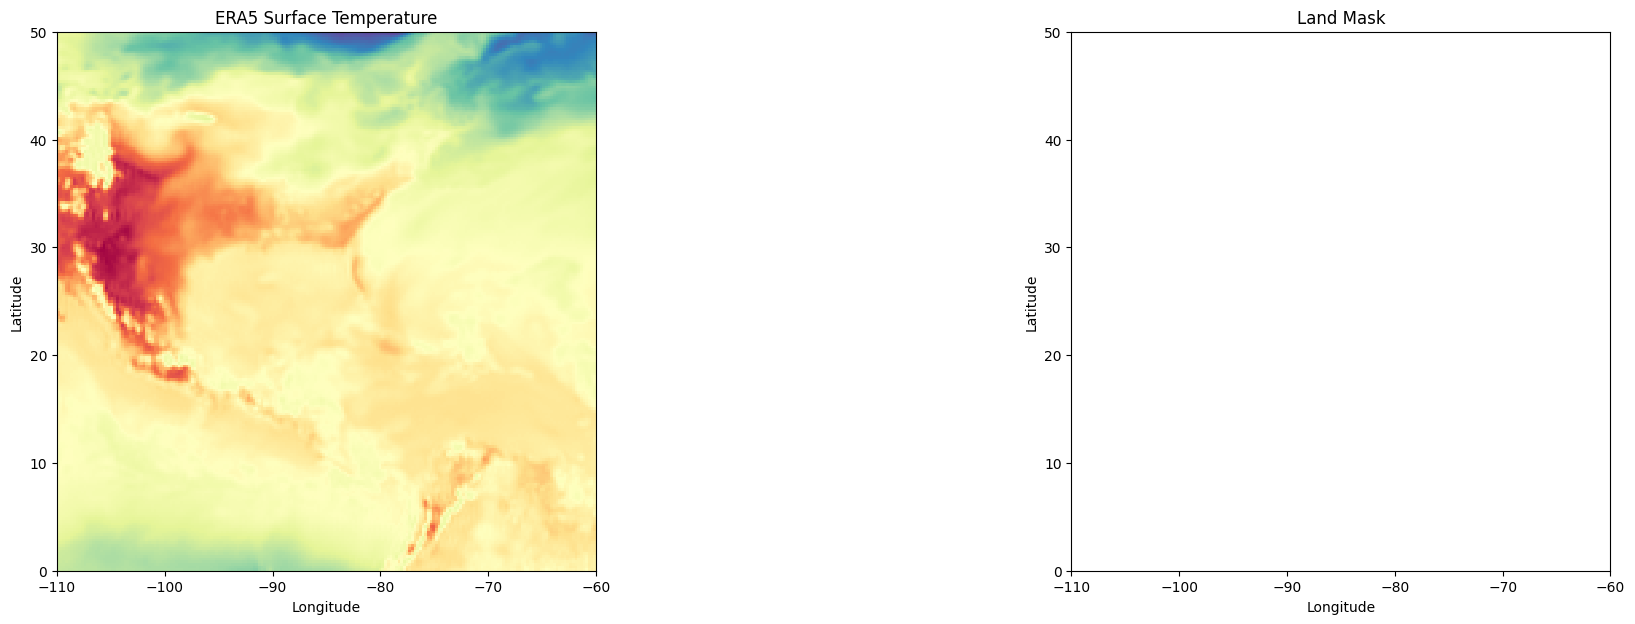

In [ ]:
from cds_Downloader import add_land_mask_to_era5

name = "Hurricane_Katrina"
file_ERA = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{name.lower()}_era5.nc"
region = 'North America'

# Use the downloaded ORAS5 file
file_land = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\sosaline_control_monthly_highres_2D_202001_OPER_v0.1.nc"
output_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{name.lower()}_era5_with_land.nc"
Regions = {
    'North America': [50, -110, 0, -60],
    'Europe': [75, -25, 35, 40],
    'South China Sea': [40, 100, 0, 150],
}

# Run the function to add land mask
add_land_mask_to_era5(file_land, file_ERA, output_file, Regions, region)

In [5]:
from PCHIP_Interpolation import pchip_interpolate_era5

name = "Typhoon_Ragasa"

input_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\typhoon_ragasa_era5_with_land.nc"

interpolated_output_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{name.lower()}_era5_1hour_pchip.nc"

interpolated_dataset = pchip_interpolate_era5(
    input_file=input_file,
    output_file=interpolated_output_file,
    substeps=6, # Based on 6 hr intervals: 4 : 1.5-hourly data; 6 : 1-hourly data; 12 : 30-minutely data;
)

Detected 6-hour intervals, creating 6 substeps
Interpolating t...
  Valid interpolations: 365192/388332 (94.0%)
  Preserved patterns: 23140/388332 (6.0%)
Interpolating u...
  Valid interpolations: 365192/388332 (94.0%)
  Preserved patterns: 23140/388332 (6.0%)
Interpolating v...
  Valid interpolations: 365192/388332 (94.0%)
  Preserved patterns: 23140/388332 (6.0%)
Interpolating w...
  Valid interpolations: 365192/388332 (94.0%)
  Preserved patterns: 23140/388332 (6.0%)
Computing wind speed...
Original: 36 timesteps
Interpolated: 211 timesteps
Expansion factor: 5.9x


c:\Users\Matt\Downloads\CDS_To_Visual_Latest\PCHIP_Interpolation.py:116: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.

c:\Users\Matt\Downloads\CDS_To_Visual_Latest\PCHIP_Interpolation.py:117: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.

c:\Users\Matt\Downloads\CDS_To_Visual_Latest\PCHIP_Interpolation.py:118: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.



In [2]:
from PCHIP_Interpolation import pchip_interpolate_era5


name = "Hurricane_Katrina"

input_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\hurricane_katrina_era5_with_land.nc"

interpolated_output_file = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{name.lower()}_era5_1hour_pchip.nc"

# custom_params = {
#     'f': 1e-4,      # Coriolis parameter
#     'g': 9.81,      # Gravity
#     'R': 287,       # Gas constant
#     'cp': 1004,     # Specific heat
#     'damping': 0.05 # Reduced damping for more dynamic behavior
# }

interpolated_dataset = pchip_interpolate_era5(
    input_file=input_file,
    output_file=interpolated_output_file,
    # compute_wind_speed=True,
    # physics_params=custom_params,
    substeps=8 # Based on 6 hr intervals: 4 : 1.5-hourly data; 6 : 1-hourly data; 12 : 30-minutely data;
)

Detected 6-hour intervals, creating 8 substeps
Interpolating t...
  Valid interpolations: 463127/484812 (95.5%)
  Preserved patterns: 21685/484812 (4.5%)
Interpolating u...
  Valid interpolations: 463127/484812 (95.5%)
  Preserved patterns: 21685/484812 (4.5%)
Interpolating v...


MemoryError: Unable to allocate 1.02 GiB for an array with shape (282, 12, 201, 201) and data type float64

---

# Analyzing Newly Constructed Files

---

In [ ]:
#from RawFile_Analysis import verifyFile, visualizeTopBottomLevels

#file = rf"D:\OneDrive\Desktop\CDS_Hurricane_Pipeline\{name.lower()}_era5_with_land.nc"
#verifyFile(file)
#visualizeTopBottomLevels(file)

---

# Visualization

---

In [7]:
# # EVENT COINFIGURATION
# region = 'South China Sea'  # Choose: 'North America', 'Europe', 'South China Sea'
# year = "2025"
# month = "09"
# day_start = 20; day_end = 23
# name = "Typoon_Ragasa_ALLVARIABLES"

# # Fixed regional coordinate grids
# Regions = {
#     'North America': [50, -135, 0, -45],      # [North, West, South, East]
#     'Europe': [75, -25, 35, 40],
#     'South China Sea': [45, 90, -15, 155],    # 45 to -15 N, 90 to 155 E [50x65 degree box]
# }

# # Generate day list
# days = [f"{day:02d}" for day in range(day_start, day_end + 1)]
# days

# # Your Hurricane Katrina request
# era5_request = {
#     'product_type': 'reanalysis',
#     'variable': [
#         'u_component_of_wind',
#         'v_component_of_wind', 
#         'vertical_velocity',
#         'potential_vorticity',
#         'temperature',
#         'specific_humidity',
#         'geopotential',
#     ],
#     'area': Regions[region], 
#     'pressure_level': [
#         '1000', '950', '900', '850', '700', '650', '600', 
#         '550', '500', '450', '400', '350', '300', '250', 
#         '200', '150', '100', '50'
#     ],
#     'year': [year],
#     'month': [month],
#     'day': days,
#     'time': [f"{hour:02d}:00" for hour in range(0, 24, 3)], # This is done with a 'list comprehension': '0' is filer, '2' is decimal places, 'd' is type (decimal integer)
#     'grid': [0.25, 0.25],
#     'format': 'netcdf',
#     'expver': '1',
#     'levtype': 'pl',
#     'stream': 'oper',
#     'type': 'an'
# }

from NetCDF_Visualizer import create_era5_wind_visualization
from matplotlib.colors import ListedColormap, to_rgba

#filePath = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\typoon_ragasa_allvariables_era5_interpolated.nc"
interpolation_method = "PCHIP"
name = "Hurricane_Katrina"
output_filename = f"{name}_{interpolation_method}_WS"; region = 'North America'
# filePath = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\{output_filename}.nc"
filePath = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\hurricane_katrina_era5_1hour_pchip.nc"

# Custom Colormap For Volume
colors1 = ["black", "black", "purple", "purple",
           "crimson","red","orangered", "orange",
           "gold", "yellow", "yellowgreen", "limegreen",
           "mediumaquamarine", "mediumturquoise", "skyblue", "aliceblue",
           "lightblue", "lightblue", "lavender",
           "white"] 

colors2 = ["black", "crimson", "red", "orangered", "orange",
           "gold", "yellow", "yellowgreen", "limegreen", "mediumaquamarine",
           "mediumturquoise", "lightcyan", "aliceblue", "white"]

# Custom Colormap For Arrows (shades of black)
#arrCol = ["dimgrey","dimgrey"]

streamline_colormap = ["aliceblue", "lightcyan", "paleturquoise", "skyblue", 
          "deepskyblue", "dodgerblue", "mediumturquoise", "mediumaquamarine", 
          "lightgreen", "limegreen", "greenyellow", "yellow", "gold", 
          "orange", "darkorange", "orangered", "orangered", "red", "red",
          "crimson", "darkred", "darkred", "maroon", "maroon", "maroon", 
          "black", "black", "black", "black", "black", "black", "black", "black", "black",
          "black", "black", "black", "black", "black", "black", "black", "black", "black"]

# gradient from white to black with an exponential decay
arrow_colormap = ["white", "gainsboro", "lightgray", "silver", "darkgray",
                   "gray", "dimgray", "dimgrey", "slategray", "lightslategray",
                   "darkslategray", "black", "black", "black", "black", "black", "black", "black", "black", "black"] 

colors1.reverse()
colors2.reverse()
# streamline_colormap.reverse() 
arrow_colormap.reverse()
cm = ListedColormap([to_rgba(color) for color in colors2])
arrCM = ListedColormap([to_rgba(color) for color in arrow_colormap])
streamline_CM = ListedColormap([to_rgba(color) for color in streamline_colormap])


variable = "wind_speed"

fps = 120
# Create ERA5 visualization (update path to your NetCDF file)
fig = create_era5_wind_visualization(
    netcdf_path=filePath, 
    stormName=name,
    variable=variable,
    pressure_range=(500, 1013), 
    latitude_range=(0, 45),  #[South, North]
    longitude_range=(-110, -65),  #[West, East]
    #     'North America': [50, -110, 0, -60],      # [North, West, South, East] 
    #     'Europe': [75, -25, 35, 40],
    #     'South China Sea': [40, 100, 0, 150],    # 45 to -15 N, 90 to 155 E [50x65 degree box]
    colormap_to_use= cm, 
    arrcolormap_to_use= streamline_CM, #arrCM,
    save_html=True,
    output_filename=rf"{output_filename.lower()}_Interpolated.html",
    subsample_factor_lat=12, 
    subsample_factor_lon=12,
    arrSubsample_factor_lat=8,
    arrSubsample_factor_lon=8,
    arrow_length=1.5, 
    arrow_thickness=2,
    arrowhead_size=0.2,
    arrOpacity=0.7,
    volume_opacity=0.15,
    landMarkerSize=2.0,
    vScale=2.8,
    filterVectors=True,
    threshold_percentile=80,
    save_animation=True,
    animation_fps= fps,
    region=region,
    animation_filename=rf"{output_filename.lower()}_Animation_{fps}fps.html",
    show_arrows=True,
    time_k=0
    )


=== ERA5 HURRICANE VISUALIZATION PIPELINE ===

Loading ERA5 NetCDF data...
Dataset variables: ['t', 'u', 'v', 'w', 'wind_speed']
Dataset dimensions: {'valid_time': 211, 'pressure_level': 12, 'latitude': 201, 'longitude': 201}

=== Applying geographic filtering ===


c:\Users\Matt\Downloads\CDS_To_Visual_Latest\NetCDF_Visualizer.py:112: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.



Filtered latitude >= 0
Filtered latitude <= 45
Filtered longitude >= -110
Filtered longitude <= -65
Filtered dataset dimensions: {'valid_time': 211, 'pressure_level': 12, 'latitude': 181, 'longitude': 181}
Available time steps: 211
Animation mode: Processing all 211 time steps

=== Calculating global wind speed range for consistent animation scale ===


c:\Users\Matt\Downloads\CDS_To_Visual_Latest\NetCDF_Visualizer.py:134: FutureWarning:

The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.



Global wind speed range (filtered, 80th percentile): 11.4 - 56.8 m/s
Color range (5th-95th percentile): 11.7 - 26.0 m/s (42 - 94 km/h)
All frames will use this consistent scale
Filtered pressure levels: [ 500.  550.  600.  650.  700.  850.  900.  950. 1000. 1013.]

=== Pre-calculating coordinate systems ===
Native resolution - Lons: 181, Lats: 181, Levels: 10
Volume coordinates - Lons: 16, Lats: 16, Levels: 10
Arrow coordinates - Lons: 23, Lats: 23, Levels: 10
=== Coordinate systems pre-calculated ===

Converted matplotlib colormap to plotly format with 14 colors
Converted matplotlib colormap to plotly format with 43 colors

--- Processing time step 0/210 ---
Wind data shape: (10, 181, 181)
Using pre-calculated NATIVE resolution coordinates...
Native data shape: (327610,)
Applying volume subsampling (using pre-calculated coordinates)...
Volume subsampled shape: (10, 16, 16)
Using wind speed for volume rendering
Applying wind arrow subsampling (using pre-calculated coordinates)...
Arrow

In [ ]:
import xarray as xr
filePath = rf"C:\Users\Matt\Downloads\CDS_To_Visual_Latest\hurricane_katrina_allvariables_era5_with_land.nc"
# Check for all variables in the dataset
dataset = xr.open_dataset(filePath)
print("Variables in the dataset:")
for var in dataset.data_vars:
    print(f"- {var}")

C:\Users\Matt\AppData\Roaming\Python\Python311\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
c:\Users\Matt\anaconda3\Lib\site-packages\cupy\_environment.py:217: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


Variables in the dataset:
- t
- u
- v
- w
- potential_vorticity
- specific_humidity
- geopotential
